In [8]:
# key-vale
path_log2 = "/home/vo43/cartridges/outputs/2026-05-30-14-51-27-continual/d13216fa-c7bb-44b7-ad10-0da585b0fa6e/sparse_slot_log.pt"
import torch

log2 = torch.load(path_log2)


In [ ]:
log2[0]

AttributeError: 'list' object has no attribute 'keys'

In [5]:
path_log = '/home/vo43/cartridges/outputs/2026-05-30-16-20-08-continual/de2bbccb-6382-41c4-93aa-46fb5c56cef0/sparse_slot_log.pt'
import torch

log = torch.load(path_log)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
except ImportError:
    torch = None


def to_numpy(x):
    if torch is not None and torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def build_selection_matrix(log, n_slots=1024):
    num_steps = len(log)
    mat = np.zeros((num_steps, n_slots), dtype=np.uint8)
    positions_per_step = []
    step_labels = []

    for row_idx, record in enumerate(log):
        pos = to_numpy(record["top_positions"]).astype(int).ravel()

        pos = pos[(pos >= 0) & (pos < n_slots)]
        pos = np.unique(pos)

        mat[row_idx, pos] = 1
        positions_per_step.append(pos)

        # Use the actual recorded step value
        step_labels.append(record.get("step", row_idx))

    return mat, positions_per_step, step_labels


def plot_top_positions(log, n_slots=1024, bin_size=16, save_path=None):
    mat, positions_per_step, step_labels = build_selection_matrix(
        log,
        n_slots=n_slots
    )

    num_steps = len(log)
    n_bins = int(np.ceil(n_slots / bin_size))

    padded_width = n_bins * bin_size
    padded = np.zeros((num_steps, padded_width), dtype=np.uint8)
    padded[:, :n_slots] = mat

    binned = padded.reshape(num_steps, n_bins, bin_size).sum(axis=2)

    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.2, 1.4, 1.4])

    # --------------------------------------------------
    # 1. Exact selected slots
    # --------------------------------------------------
    ax1 = fig.add_subplot(gs[0])

    for row_idx, pos in enumerate(positions_per_step):
        y = np.full_like(pos, row_idx)
        ax1.scatter(pos, y, marker="|", s=120, linewidths=1.2)

    ax1.set_title("Exact selected top-t slots per recorded step")
    ax1.set_xlabel("Slot index")
    ax1.set_ylabel("Recorded step")
    ax1.set_xlim(-1, n_slots)
    ax1.set_yticks(range(num_steps))
    ax1.set_yticklabels([f"step {s}" for s in step_labels])
    ax1.grid(axis="x", alpha=0.25)

    # --------------------------------------------------
    # 2. Binary heatmap
    # --------------------------------------------------
    ax2 = fig.add_subplot(gs[1])

    im2 = ax2.imshow(
        mat,
        aspect="auto",
        interpolation="nearest",
        origin="lower",
    )

    ax2.set_title("Binary heatmap: selected = 1, not selected = 0")
    ax2.set_xlabel("Slot index")
    ax2.set_ylabel("Recorded step")
    ax2.set_yticks(range(num_steps))
    ax2.set_yticklabels([f"step {s}" for s in step_labels])
    fig.colorbar(im2, ax=ax2, label="selected")

    # --------------------------------------------------
    # 3. Binned density heatmap
    # --------------------------------------------------
    ax3 = fig.add_subplot(gs[2])

    im3 = ax3.imshow(
        binned,
        aspect="auto",
        interpolation="nearest",
        origin="lower",
    )

    ax3.set_title(f"Binned density heatmap, bin size = {bin_size} slots")
    ax3.set_xlabel("Slot bin start index")
    ax3.set_ylabel("Recorded step")
    ax3.set_yticks(range(num_steps))
    ax3.set_yticklabels([f"step {s}" for s in step_labels])

    tick_bins = np.linspace(0, n_bins - 1, min(9, n_bins), dtype=int)
    ax3.set_xticks(tick_bins)
    ax3.set_xticklabels([f"{b * bin_size}" for b in tick_bins])

    fig.colorbar(im3, ax=ax3, label="# selected slots in bin")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

    return mat, binned

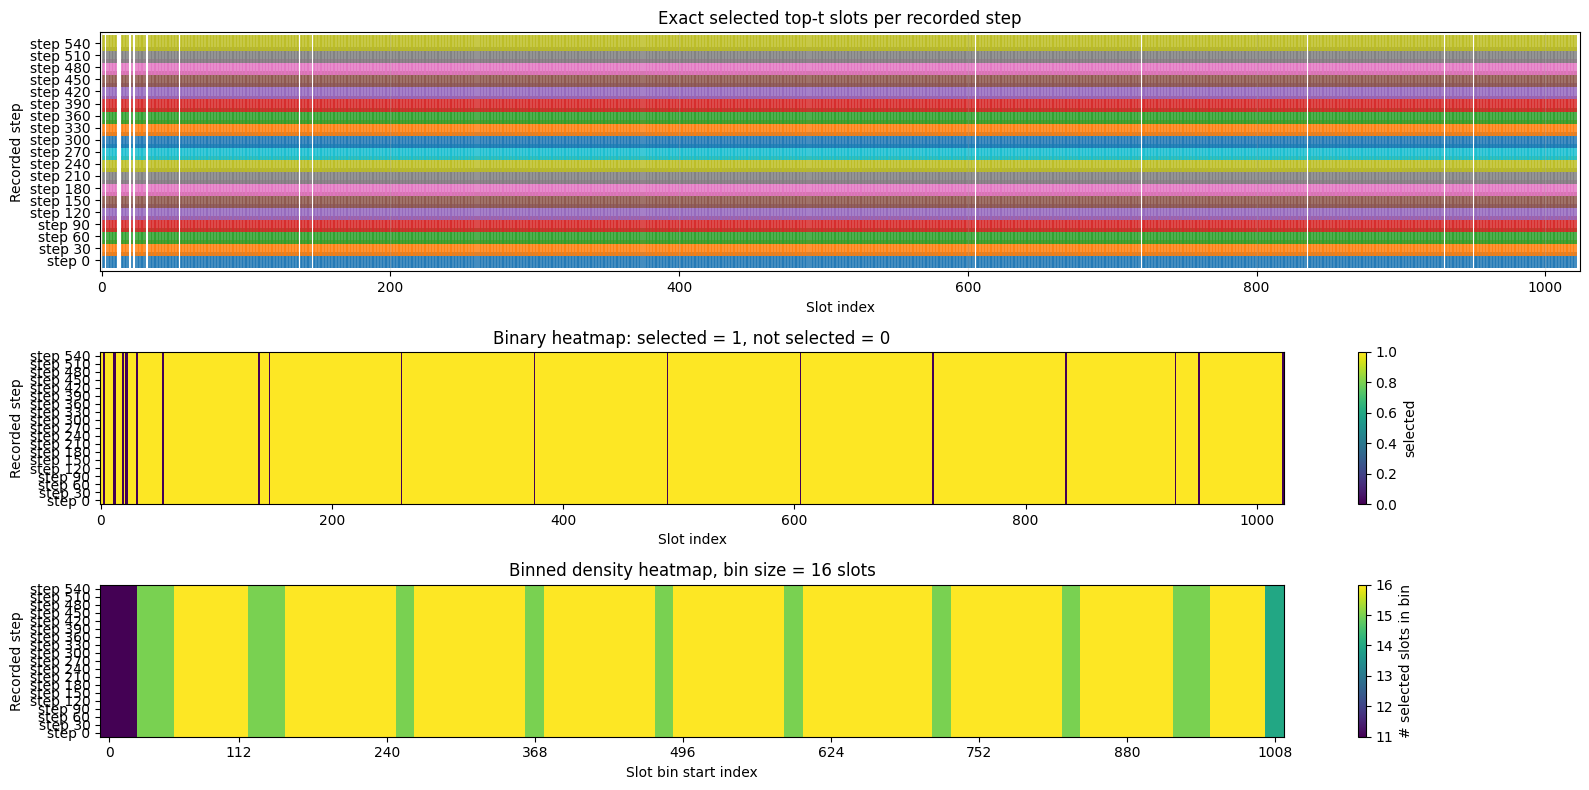

In [7]:
mat, binned = plot_top_positions(
    log,
    n_slots=1024,
    bin_size=16,
    save_path="top_positions_heatmap.png"
)

In [48]:
path = "/home/vo43/cartridges/outputs/2026-05-28-05-34-31-continual/3b675600-f877-44fc-bbe6-9a1f65250718/bg_stats.pt"
import torch

bg = torch.load(path)


In [26]:
bg.keys()

dict_keys(['batch_ranked_positions', 'num_batches'])

In [50]:
bg["batch_ranked_positions"].shape

torch.Size([903, 1023])

In [32]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
except ImportError:
    torch = None

# Optional: for better sample ordering
try:
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False


def to_numpy(x):
    if torch is not None and torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def build_rank_matrix(batch_ranked_positions, n_slots=None):
    """
    batch_ranked_positions:
        shape [n_samples, n_ranked_slots]
        Each row contains slot IDs ordered from most important to least important.

    Returns:
        rank_matrix: shape [n_samples, n_slots]
            rank_matrix[i, slot] = rank position of that slot for sample i
            smaller = more important
    """
    ranked = to_numpy(batch_ranked_positions).astype(int)
    n_samples, n_ranked_slots = ranked.shape

    if n_slots is None:
        n_slots = int(ranked.max()) + 1

    # Default fill = n_ranked_slots (or n_slots) for unseen slots
    rank_matrix = np.full((n_samples, n_slots), fill_value=n_ranked_slots, dtype=np.int32)

    row_idx = np.arange(n_samples)[:, None]
    rank_idx = np.arange(n_ranked_slots)[None, :]
    rank_matrix[row_idx, ranked] = rank_idx

    return rank_matrix


def reorder_samples(rank_matrix, method="cluster"):
    """
    Reorder rows so similar samples are near each other.
    """
    n_samples = rank_matrix.shape[0]

    if method == "none":
        return np.arange(n_samples)

    if method == "cluster" and SCIPY_AVAILABLE:
        # Correlation distance on rows
        dist = pdist(rank_matrix, metric="correlation")
        Z = linkage(dist, method="average")
        order = leaves_list(Z)
        return order

    # Fallback: sort by average rank of top slots
    # (not as strong as clustering, but still useful)
    score = rank_matrix[:, :].mean(axis=1)
    return np.argsort(score)


def plot_slot_importance_heatmaps(batch_ranked_positions, n_slots=None, top_k=32, reorder="cluster"):
    ranked = to_numpy(batch_ranked_positions).astype(int)
    rank_matrix = build_rank_matrix(ranked, n_slots=n_slots)

    n_samples, n_slots = rank_matrix.shape

    # Reorder rows for visual similarity
    sample_order = reorder_samples(rank_matrix, method=reorder)
    rank_matrix_ord = rank_matrix[sample_order]

    # Normalize ranks to [0, 1] for easier plotting
    rank_norm = rank_matrix_ord / max(1, rank_matrix_ord.shape[1] - 1)

    # Top-k frequency per slot
    topk_mask = rank_matrix < top_k
    topk_freq = topk_mask.mean(axis=0)  # fraction of samples where slot appears in top-k

    # Mean rank per slot
    mean_rank = rank_matrix.mean(axis=0)

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[5, 1.5, 1.5])

    # --------------------------------------------------
    # 1) Main rank heatmap
    # --------------------------------------------------
    ax1 = fig.add_subplot(gs[0])
    im = ax1.imshow(
        rank_norm,
        aspect="auto",
        interpolation="nearest",
        origin="lower",
    )
    ax1.set_title("Sample × Slot Rank Heatmap (darker/lower = more important)")
    ax1.set_xlabel("Slot ID")
    ax1.set_ylabel("Sample (reordered by similarity)")
    cbar = fig.colorbar(im, ax=ax1)
    cbar.set_label("Normalized rank (0 = most important)")

    # --------------------------------------------------
    # 2) Top-k frequency across samples
    # --------------------------------------------------
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(np.arange(n_slots), topk_freq)
    ax2.set_title(f"Fraction of samples where slot is in Top-{top_k}")
    ax2.set_xlabel("Slot ID")
    ax2.set_ylabel("Frequency")

    # --------------------------------------------------
    # 3) Mean rank of each slot
    # --------------------------------------------------
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(np.arange(n_slots), mean_rank)
    ax3.set_title("Mean rank per slot across samples")
    ax3.set_xlabel("Slot ID")
    ax3.set_ylabel("Mean rank (smaller = more important)")

    plt.tight_layout()
    plt.show()

    return {
        "rank_matrix": rank_matrix,
        "sample_order": sample_order,
        "topk_frequency": topk_freq,
        "mean_rank": mean_rank,
    }

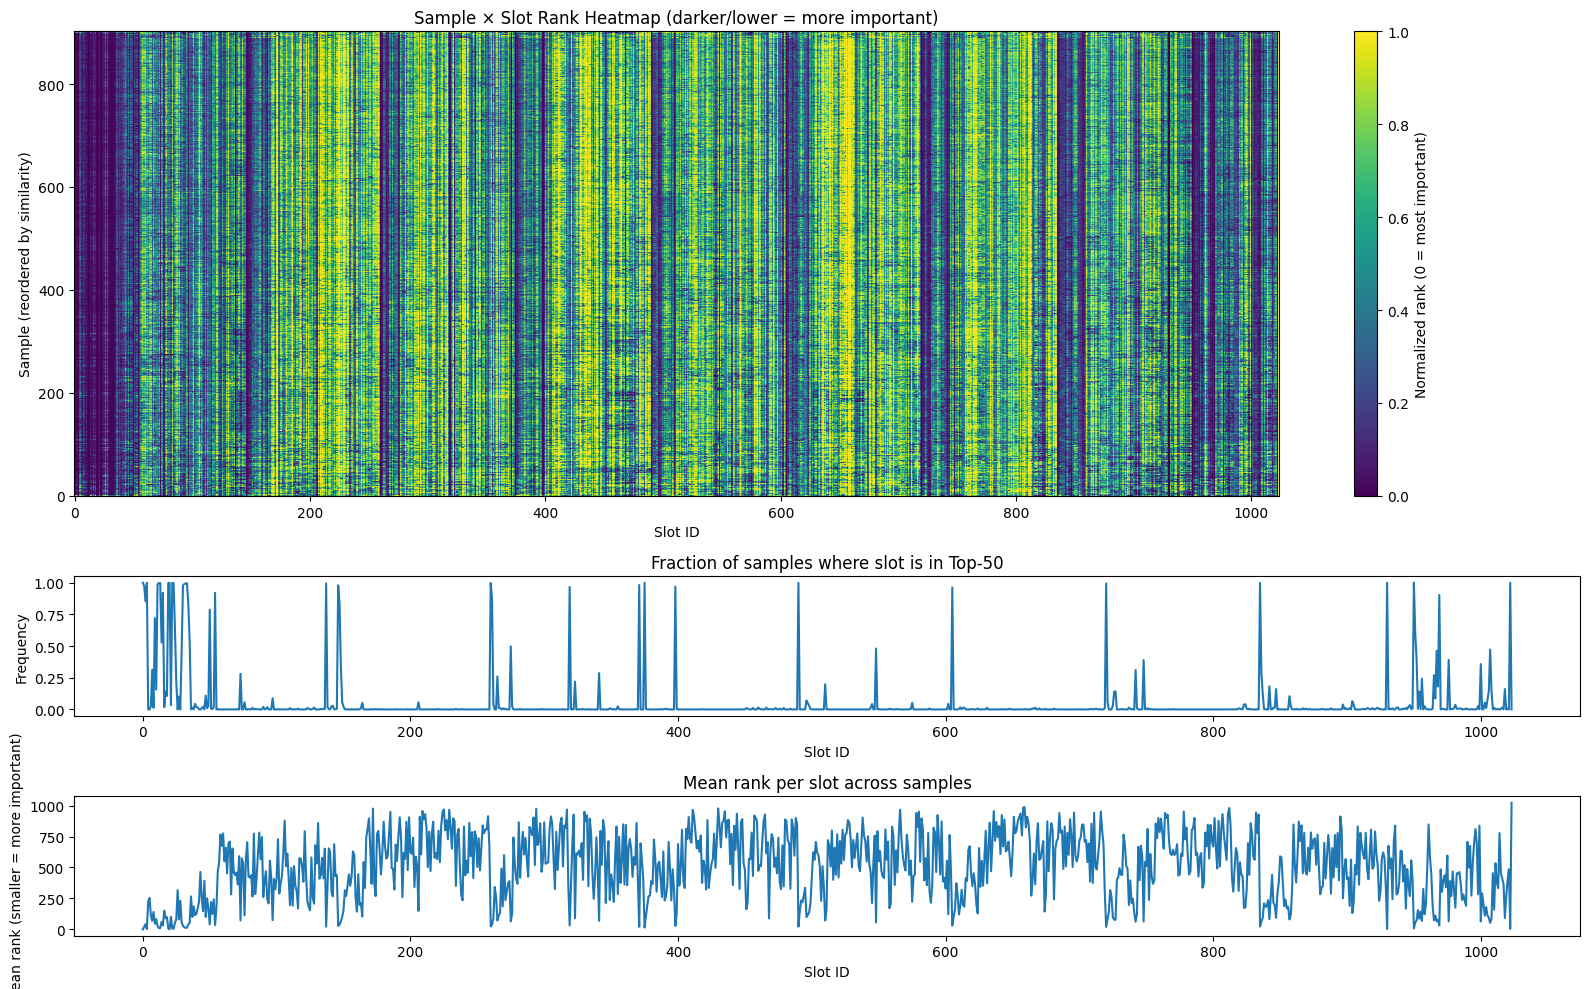

In [37]:
results = plot_slot_importance_heatmaps(
    bg["batch_ranked_positions"],
    n_slots=1024,   # or omit if inferred automatically
    top_k=50,
    reorder="cluster"
)

In [38]:
path_init = "/home/vo43/cartridges/outputs/2026-05-28-03-57-51-initial/42a82b24-75f3-4bd8-b77f-447f3bb5d07f/bg_stats.pt"
bg_init = torch.load(path_init)

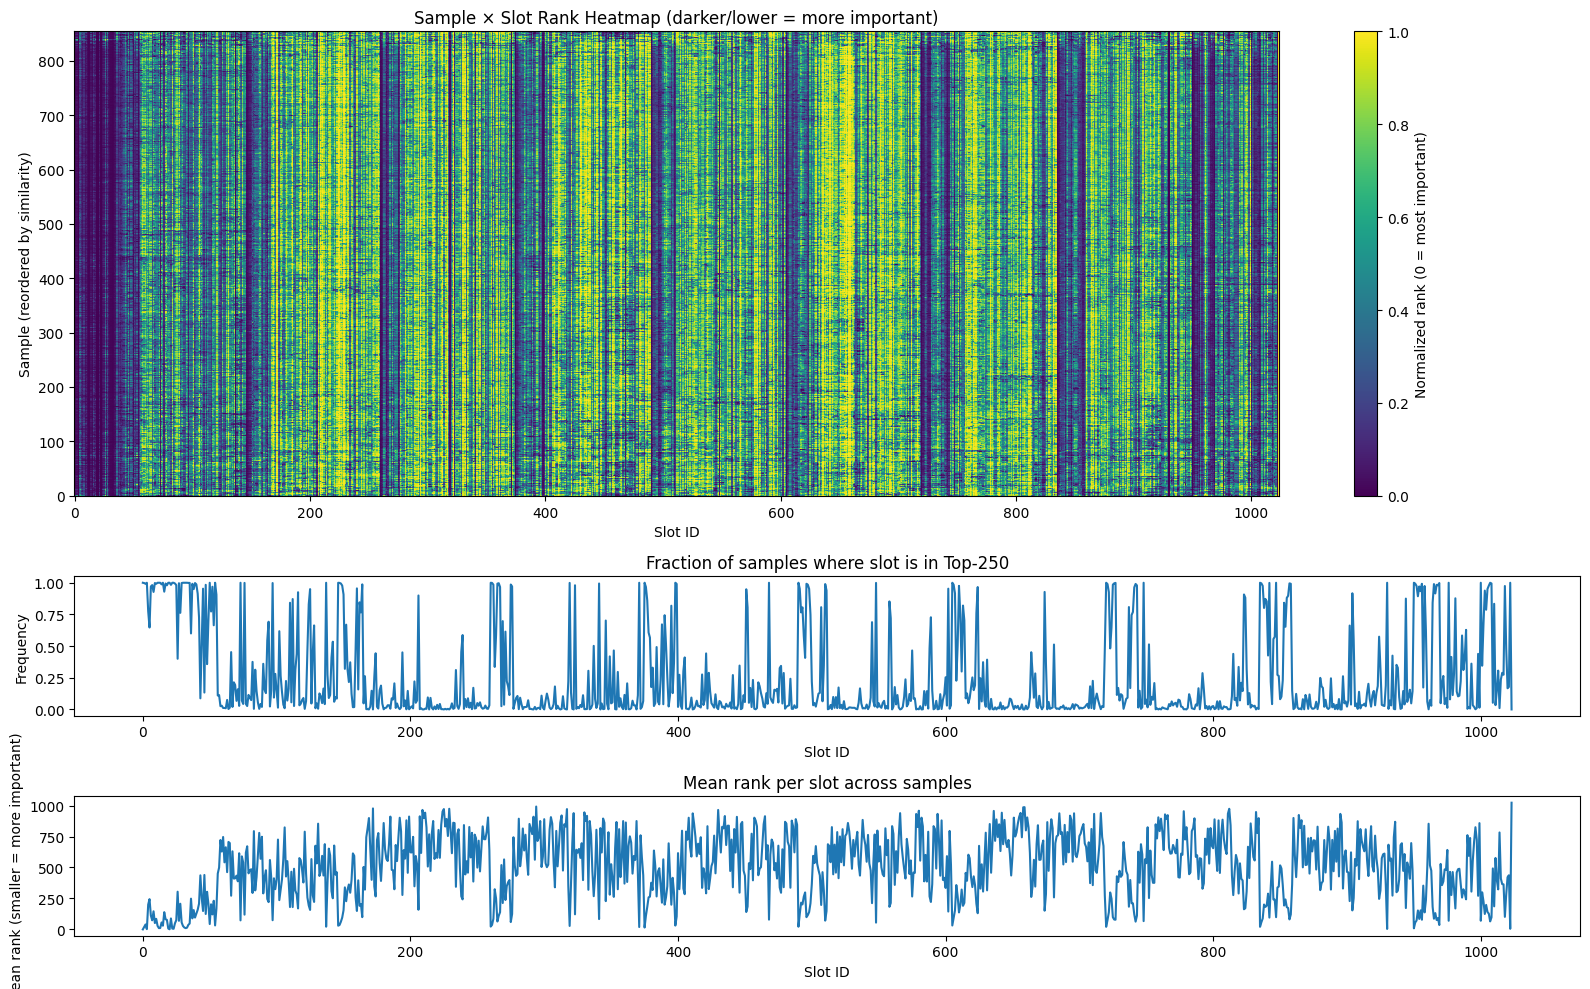

In [41]:
results = plot_slot_importance_heatmaps(
    bg_init["batch_ranked_positions"],
    n_slots=1024,   # or omit if inferred automatically
    top_k=250,
    reorder="cluster"
)

In [19]:
len(bg["position_to_batches"].keys())

859

In [3]:
from collections import defaultdict

def invert_mapping(original_dict):
    """
    Convert a dictionary of:
        key -> list of values

    into:
        value -> list of keys
    """
    inverted = defaultdict(list)

    for key, values in original_dict.items():
        for value in values:
            inverted[value].append(key)

    return dict(inverted)

inversed_mapping = invert_mapping(bg["position_to_batches"])

print(inversed_mapping)

{0: [0, 20, 3, 930, 22, 23, 12, 1022, 32, 19, 13, 950, 73, 33, 375, 31, 146, 137, 323, 15, 47, 847, 631, 490, 398, 498, 260, 147, 34, 371, 497, 48, 500, 319, 30, 846, 11, 2, 261, 333, 720, 548, 9, 49, 835, 845, 976, 50, 605, 269, 29, 206, 7, 314, 54, 842, 628, 663, 1007, 302, 262, 141, 155, 35, 735, 499, 1, 128, 327, 10, 76, 506, 17, 341, 16, 626, 148, 275, 271, 110, 524, 329, 116, 501, 858, 301, 839, 392, 507, 14, 1000, 328, 45, 748, 468, 307, 267, 920, 399, 27, 424, 103, 265, 518, 545, 505, 24, 186, 857, 662, 39, 496, 205, 951, 588, 944, 969, 102, 484, 149, 619, 203, 343, 561, 97, 952, 837, 391, 266, 836, 848, 916, 742, 520, 681, 613, 349, 915, 953, 584, 112, 843, 8, 606, 550, 55, 954, 6, 395, 630, 423, 124, 79, 650, 629, 510, 390, 123, 922, 867, 198, 394, 708, 624, 569, 160, 602, 782, 536, 968, 404, 479, 21, 310, 388, 575, 1006, 558, 331, 80, 40, 177, 405, 618, 783, 648, 451, 981, 529, 142, 276, 888, 282, 623, 159, 767, 727, 862, 41, 849, 632, 851, 283, 607, 52, 645, 743, 556, 93, 5

In [4]:
len(inversed_mapping[10])

1000

In [6]:
sorted(inversed_mapping[0])

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 171,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,


In [22]:
from datasets import load_dataset

ds = load_dataset("qtris123/qasper_self_study_65k_qwen3-4b-instruct-2507_qa")

README.md:   0%|          | 0.00/866 [00:00<?, ?B/s]

data/train-00000-of-00010.parquet:   0%|          | 0.00/361M [00:00<?, ?B/s]

data/train-00001-of-00010.parquet:   0%|          | 0.00/359M [00:00<?, ?B/s]

data/train-00002-of-00010.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

data/train-00003-of-00010.parquet:   0%|          | 0.00/374M [00:00<?, ?B/s]

...

data/train-00006-of-00010.parquet:   0%|          | 0.00/371M [00:00<?, ?B/s]

data/train-00007-of-00010.parquet:   0%|          | 0.00/356M [00:00<?, ?B/s]

data/train-00008-of-00010.parquet:   0%|          | 0.00/360M [00:00<?, ?B/s]

data/train-00009-of-00010.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/65536 [00:00<?, ? examples/s]

In [23]:
import os
from transformers import AutoTokenizer

token_ids_to_test = ds["train"][0]['messages'][0]['token_ids']
# Target repositories to check against
MODELS_TO_CHECK = {
    "Qwen3-2507 (4B variant)": "Qwen/Qwen3-4B-Instruct-2507",
    "Llama-3.2 (3B variant)": "meta-llama/Llama-3.2-3B-Instruct"
}

# =====================================================================
# 2. VALIDATION FUNCTION
# =====================================================================

def test_token_coherence(token_ids, model_name, repo_id):
    print("\n" + "="*60)
    print(f"🔍 TESTING MODEL: {model_name}")
    print(f"📂 Repository: {repo_id}")
    print("="*60)
    
    try:
        # Load the tokenizer. Ensure HF_TOKEN is in your environment for Llama access.
        tokenizer = AutoTokenizer.from_pretrained(repo_id, token=os.getenv("HF_TOKEN", True))
        
        # FIX: len(tokenizer) includes base vocabulary AND added/special tokens (like 128009)
        total_vocab_size = len(tokenizer)
        print(f"📊 True Tokenizer Vocabulary Size (with Special Tokens): {total_vocab_size:,}")
        
        # ---- STEP 1: Bound Checking ----
        out_of_bounds = [t for t in token_ids if t < 0 or t >= total_vocab_size]
        
        if out_of_bounds:
            print(f"❌ RANGE CHECK FAILED!")
            print(f"   ↳ Found {len(out_of_bounds)} tokens completely outside this model's vocabulary.")
            print(f"   ↳ Your data max ID: {max(token_ids)} | Model allowed limit: {total_vocab_size - 1}")
            print(f"   ↳ Sample invalid tokens: {out_of_bounds[:5]}")
            print("\n❌ VERDICT: These tokens will CRASH this model. They belong to a different vocabulary entirely.")
            return False
            
        print("✅ RANGE CHECK PASSED: All token IDs fall within acceptable index ranges.")
        
        # ---- STEP 2: Semantic Decoding ----
        decoded_text = tokenizer.decode(token_ids, skip_special_tokens=False)
        
        print("\n📝 DECODED TEXT OUTPUT preview:")
        print("-" * 50)
        print(decoded_text[:1000] + ("..." if len(decoded_text) > 1000 else ""))
        print("-" * 50)
        
        print("\n💡 VERDICT TIME:")
        print("   👉 Read the text block above carefully.")
        print("   👉 If it looks like normal, structured chat/English, these IDs belong to this model.")
        print("   👉 If it looks like continuous scrambled text, emojis, or random blocks, the vocabulary is a mismatch.")
        
        return True

    except Exception as e:
        print(f"💥 Error loading/processing {model_name}: {e}")
        print("   Tip: If it's a gated model like Llama, verify your Hugging Face authentication status.")
        return False

# =====================================================================
# 3. RUN TESTS
# =====================================================================
if __name__ == "__main__":
    for name, repo in MODELS_TO_CHECK.items():
        test_token_coherence(token_ids_to_test, name, repo)


🔍 TESTING MODEL: Qwen3-2507 (4B variant)
📂 Repository: Qwen/Qwen3-4B-Instruct-2507
📊 True Tokenizer Vocabulary Size (with Special Tokens): 151,669
✅ RANGE CHECK PASSED: All token IDs fall within acceptable index ranges.

📝 DECODED TEXT OUTPUT preview:
--------------------------------------------------
What is the name of the basic question generation module in the VQABQ model, and how does it formulate the problem of generating basic questions using a LASSO optimization problem, as described in Section 7 with reference to Equation (17) and the dataset details from Section 11?<|im_end|>
--------------------------------------------------

💡 VERDICT TIME:
   👉 Read the text block above carefully.
   👉 If it looks like normal, structured chat/English, these IDs belong to this model.
   👉 If it looks like continuous scrambled text, emojis, or random blocks, the vocabulary is a mismatch.

🔍 TESTING MODEL: Llama-3.2 (3B variant)
📂 Repository: meta-llama/Llama-3.2-3B-Instruct
📊 True Tokenizer

In [19]:
ds["train"][0]['messages'][0]

{'content': 'What is the name of the Co-Attention Mechanism used in the VQABQ model, and how does it sequentially alternates between generating question and image attention in the Alternating Co-Attention Mechanism?',
 'role': 'user',
 'token_ids': [3923,
  374,
  279,
  836,
  315,
  279,
  3623,
  12,
  70429,
  28901,
  2191,
  1511,
  304,
  279,
  650,
  48,
  1905,
  48,
  1646,
  11,
  323,
  1268,
  1587,
  433,
  95659,
  7064,
  988,
  1990,
  24038,
  3488,
  323,
  2217,
  6666,
  304,
  279,
  20054,
  1113,
  3623,
  12,
  70429,
  28901,
  2191,
  30,
  128009],
 'top_logprobs': None}

In [ ]:
from datasets import load_dataset

ds = load_dataset("qtris123/qasper_self_study_65k_qwen3-4b-instruct-2507_qa")

In [33]:
from datasets import load_dataset

ds = load_dataset("qtris123/qtris123qasper-rewrite-gpt-4.1-SA-task")

In [32]:
ds["question"].to_pandas()

,paper_id,title,abstract,question,answer,old_answer,old_question
0,1904.09678,UniSent: Universal Adaptable Sentiment Lexica ...,"In this paper, we introduce UniSent a universa...","In the paper ""UniSent: Universal Adaptable Sen...",Accuracy and macro-F1 (averaged F1 over positi...,{'evidence': ['FLOAT SELECTED: Table 1: Compar...,how is quality measured?
1,1904.09678,UniSent: Universal Adaptable Sentiment Lexica ...,"In this paper, we introduce UniSent a universa...",Which sentiment lexica or resources do the aut...,"Manually created sentiment lexica in Czech, Ge...",{'evidence': ['As the gold standard sentiment ...,what sentiment sources do they compare with?
2,1808.05077,Exploiting Deep Learning for Persian Sentiment...,The rise of social media is enabling people to...,"According to the paper ""Exploiting Deep Learni...",CNN achieved the highest performance in sentim...,{'evidence': ['To evaluate the performance of ...,Which deep learning model performed better?
3,1808.05077,Exploiting Deep Learning for Persian Sentiment...,The rise of social media is enabling people to...,"According to the paper ""Exploiting Deep Learni...",Accuracy of 82.6%.,{'evidence': ['To evaluate the performance of ...,What was their performance on the dataset?
4,1912.05066,Event Outcome Prediction using Sentiment Analy...,Sentiment Analysis of microblog feeds has attr...,"In the paper ""Event Outcome Prediction using S...",Two labels: sentiment polarity and candidate/c...,"{'evidence': ['For the sentiment analysis, we ...",How many label options are there in the multi-...
...,...,...,...,...,...,...,...
57,2004.03925,Word frequency and sentiment analysis of twitt...,The Coronavirus pandemic has taken the world b...,"In the paper ""Word frequency and sentiment ana...",No; the authors collect Twitter data in Englis...,"{'evidence': ['In this section, we present the...",Do they collect only English data?
58,2003.04967,KryptoOracle: A Real-Time Cryptocurrency Price...,"Cryptocurrencies, such as Bitcoin, are becomin...","In the paper ""KryptoOracle: A Real-Time Crypto...",Yes. All non-English tweets were filtered out ...,{'evidence': ['Twitter data: We used the Twitt...,Do they evaluate only on English datasets?
59,2003.04967,KryptoOracle: A Real-Time Cryptocurrency Price...,"Cryptocurrencies, such as Bitcoin, are becomin...",What experimental evaluation is used in the pa...,Root mean square error between actual and pred...,{'evidence': ['Once the KryptoOracle engine wa...,What experimental evaluation is used?
60,2003.04967,KryptoOracle: A Real-Time Cryptocurrency Price...,"Cryptocurrencies, such as Bitcoin, are becomin...","According to the paper ""KryptoOracle: A Real-T...",By leveraging Apache Spark’s resilient distrib...,{'evidence': ['KryptoOracle has been built in ...,How is the architecture fault-tolerant?
